# Assignment 2

## Task 1: Exploratory Data Analysis (EDA)

In [1]:
# ─── Library Imports ───────────────────────────────────────────────────────────
# pandas & numpy  → data manipulation and numerical operations
# matplotlib & seaborn → visualisation
# sklearn → preprocessing and train/test split utilities
# warnings → suppress non-critical warnings for cleaner output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

**Importing necessary libraries:**

The essential Python libraries are imported for data loading, manipulation, visualisation, and machine learning preprocessing.
Seaborn's whitegrid style is applied to improve the readability of all plots.

In [2]:
# Load the FIFA dataset from CSV into a pandas DataFrame
df = pd.read_csv('Fifa.csv')

# Preview the first 5 rows to understand structure and available features
print(df.head())
df= df.sample(frac=0.1, random_state= 42)
  

                 Name Country Position  Age  Overall_Rating  Future Potential  \
0  Agostinho Mabululu  Angola       LW   30              68                68   
1     Mahmoud Gennesh   Egypt       GK   35              67                67   
2      Sobhi Suleiman   Egypt       GK   28              63                65   
3        Mahmoud Alaa   Egypt       CB   32              68                68   
4     Mahmoud Shabana   Egypt       CB   30              66                66   

                 Team  Value Per M$  Total_Stats Score  
0  Ittihad Alexandria          0.65               1660  
1  Ittihad Alexandria          0.35               1620  
2  Ittihad Alexandria          0.20               1480  
3  Ittihad Alexandria          0.50               1695  
4  Ittihad Alexandria          0.40               1640  


**Load the Dataset:**

The FIFA Players dataset is loaded into a DataFrame.
The first few rows are displayed to understand the available features — Name, Country, Position, Age, Overall_Rating, Future Potential, Team, Value Per M$, and Total_Stats Score.

In [3]:
# Print dataset dimensions
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])

# Display data types and non-null counts for each column
df.info()

Number of rows: 1967
Number of columns: 9
<class 'pandas.DataFrame'>
Index: 1967 entries, 15659 to 5046
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               1967 non-null   str    
 1   Country            1967 non-null   str    
 2   Position           1967 non-null   str    
 3   Age                1967 non-null   int64  
 4   Overall_Rating     1967 non-null   int64  
 5   Future Potential   1967 non-null   int64  
 6   Team               1967 non-null   str    
 7   Value Per M$       1967 non-null   float64
 8   Total_Stats Score  1967 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 153.7 KB


In [4]:
# Count missing values per column
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values)

Missing values per column:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


- **Missing Values:**

The dataset is checked for missing values in each column.  
This step is important to ensure data quality before applying any machine learning models.

No missing values are found, the dataset is considered clean and ready for further analysis.

In [5]:
dublicate_rows = df.duplicated().sum()
print('Number of duplicate rows:', dublicate_rows)

Number of duplicate rows: 0


No dublicated values found

In [6]:
# Generate descriptive statistics for all numerical columns
# (count, mean, std, min, percentiles, max)
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000
mean,22.997458,63.096594,70.457041,2.578561,1539.312150
std,4.669166,7.885035,6.507220,8.310734,272.053977
min,16.000000,46.000000,48.000000,0.000000,789.000000
25%,19.000000,57.000000,66.000000,0.300000,1388.500000
50%,22.000000,63.000000,70.000000,0.675000,1553.000000
75%,26.000000,68.000000,75.000000,1.600000,1714.000000
max,40.000000,91.000000,95.000000,190.500000,2297.000000


**Statistical Summary:**

A summary of the numerical features is generated.
This provides a general understanding of the scale and spread of each variable and helps spot potential outliers early (e.g., max Value Per M$ = 190.5 vs mean = 2.5).

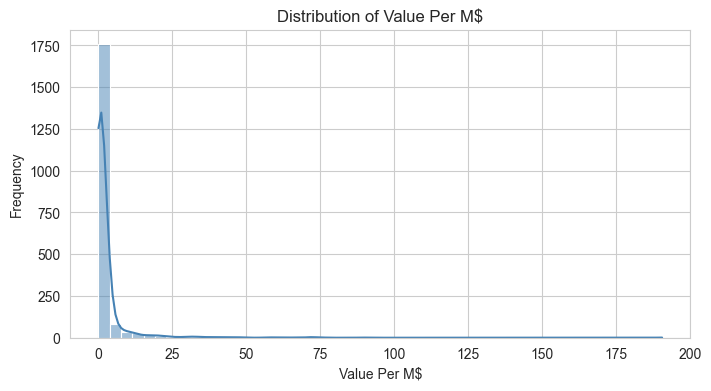

Skewness of Value Per M$: 10.079


In [7]:
# Plot the distribution of the target variable Value Per M$
plt.figure(figsize=(8, 4))
sns.histplot(df['Value Per M$'], kde=True, color='steelblue', bins=50)
plt.title('Distribution of Value Per M$')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')

plt.show()

# Compute skewness — values > 1 indicate strong right skew
print('Skewness of Value Per M$:', round(df['Value Per M$'].skew(), 4))

- **Distribution of Player Value:**

The distribution of the target variable (*Value Per M$*) is visualized using a histogram. This helps determine whether the data is normally distributed or skewed.  

The distribution of *Value Per M$* is highly right-skewed, with most players having low values and a few players having very high values.

The skewness is approximately **7.98**, indicating a strong positive skew and the presence of extreme values (outliers).

This suggests the data is not normally distributed and may require transformation or careful handling in modeling.

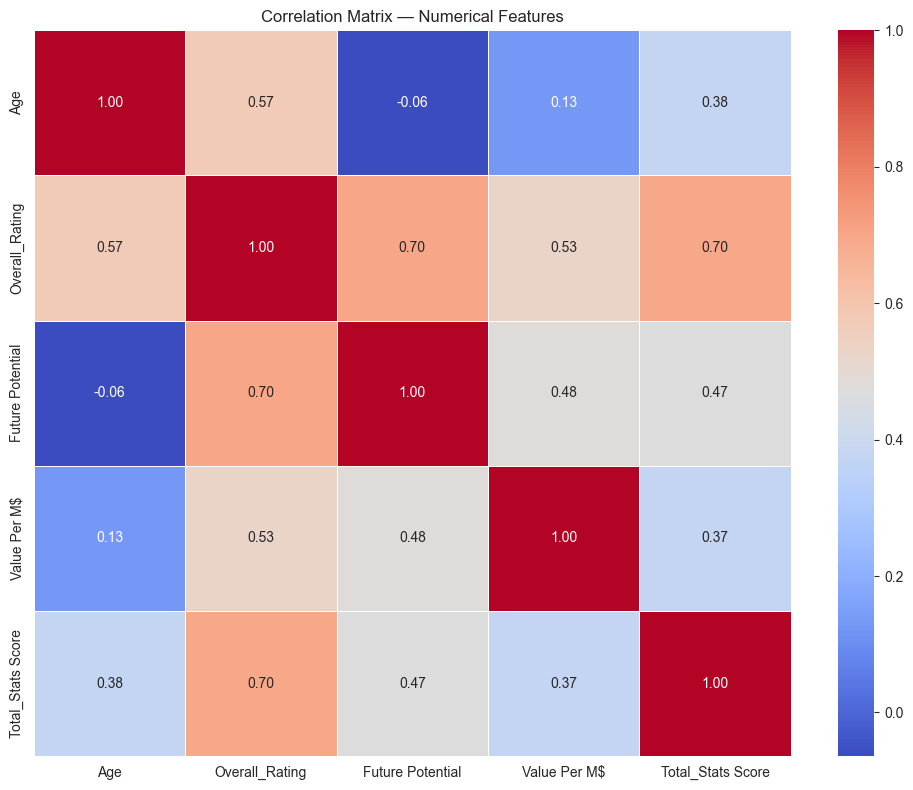


Correlation with Value Per M$:
Value Per M$         1.000000
Overall_Rating       0.528043
Future Potential     0.477907
Total_Stats Score    0.374643
Age                  0.129964
Name: Value Per M$, dtype: float64


In [8]:
# Select only numerical columns for correlation analysis
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

# Visualise the full correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

# Print sorted correlations with the target variable
print('\nCorrelation with Value Per M$:')
print(corr_matrix['Value Per M$'].sort_values(ascending=False))

**Correlation Analysis:**

The correlation matrix shows how strongly each numerical feature relates to the others and to the target.
Overall_Rating, Future Potential, and Total_Stats Score have the highest positive correlation with Value Per M$, making them the most important predictors.
Age shows a weak or negative correlation, suggesting older players are not necessarily more valuable.

Average Overall_Rating per Position:
Position
GK     61.359116
RB     61.550847
LB     61.625000
RWB    61.935484
CM     62.057034
ST     62.687273
RW     63.135135
LM     63.227642
CAM    63.790909
CB     63.990196
LWB    64.250000
RM     64.400000
LW     64.750000
CDM    65.473684
CF     65.593750
Name: Overall_Rating, dtype: float64


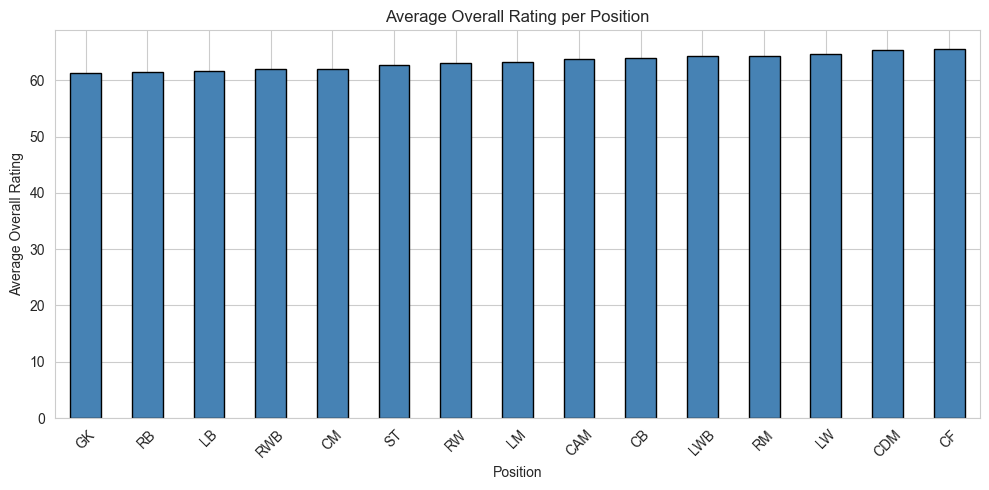

In [9]:
# Compute average Overall_Rating grouped by player position
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=True)
print('Average Overall_Rating per Position:')
print(avg_rating)

# Bar chart to compare ratings across positions visually
plt.figure(figsize=(10, 5))
avg_rating.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Overall Rating per Position')
plt.xlabel('Position')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- **Average Overall Rating per Position:**

The average Overall Rating is calculated for each player per their position.

This analysis helps understand how player performance varies across different positions on the field.  
The results are visualized using a bar chart for easier comparison.

The average Overall Rating is similar across most positions, generally ranging between 60 and 65. However, a few positions such as RF and SW have noticeably higher average ratings, indicating some variation in player performance by position.

---
## Task 2: Data Preprocessing

In [10]:
# Drop the Name column (identifier, not a feature) and separate features from target
X = df.drop(columns=['Value Per M$', 'Name'])
y = df['Value Per M$']

# Split BEFORE any preprocessing to prevent data leakage
# 80% train — 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape}  |  Test size: {X_test.shape}')

Train size: (1573, 7)  |  Test size: (394, 7)


**Train / Test Split:**

The dataset is split into 80% training and 20% test before any preprocessing.
This is critical — fitting scalers or encoders on the full dataset would leak test-set statistics into training, producing overly optimistic evaluation results.

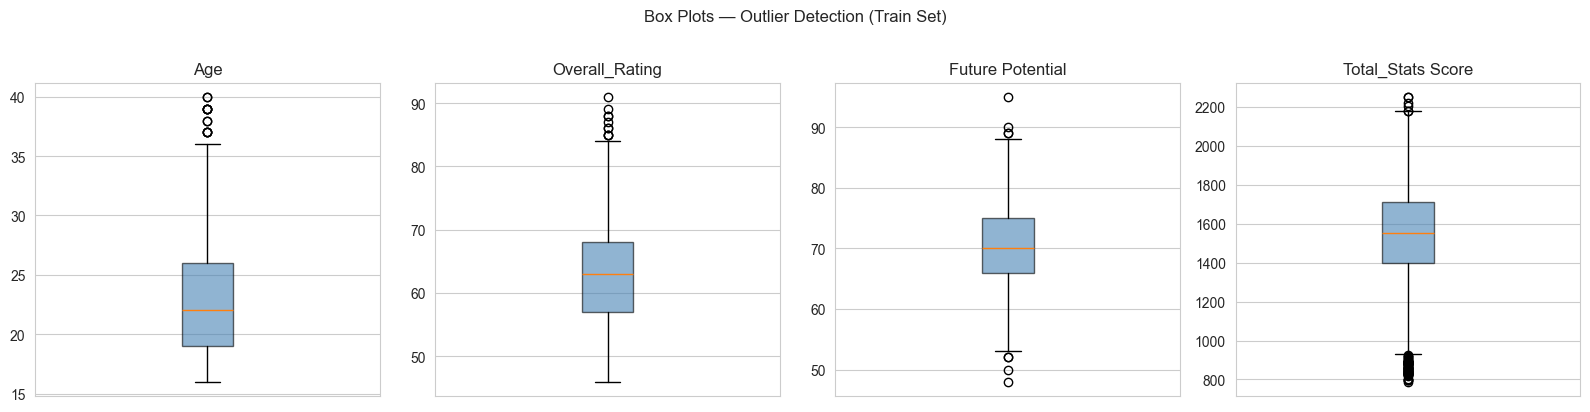

Age: 13 outliers  (lower=8.50, upper=36.50)
Overall_Rating: 10 outliers  (lower=40.50, upper=84.50)
Future Potential: 8 outliers  (lower=52.50, upper=88.50)
Total_Stats Score: 73 outliers  (lower=927.50, upper=2179.50)


In [11]:
# Visualise outliers in each numerical feature using box plots (train set only)
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(X_train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle('Box Plots — Outlier Detection (Train Set)', y=1.02)
plt.tight_layout()
plt.show()

# IQR method — count outliers outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
for col in num_cols:
    Q1  = X_train[col].quantile(0.25)
    Q3  = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f'{col}: {n_out} outliers  (lower={lower:.2f}, upper={upper:.2f})')

**Outlier Detection:**

The IQR method flags values that lie more than 1.5× the interquartile range below Q1 or above Q3.
Box plots provide a visual summary.
The target variable (Value Per M$) is the most affected due to a few elite players with extremely high market values.

In [12]:
# Detect and remove outliers in the TARGET variable (Value Per M$) using IQR
Q1_val  = y_train.quantile(0.25)
Q3_val  = y_train.quantile(0.75)
IQR_val = Q3_val - Q1_val
lower_val = Q1_val - 1.5 * IQR_val
upper_val = Q3_val + 1.5 * IQR_val

# Keep only rows whose target falls within the IQR-based bounds
outlier_mask = (y_train >= lower_val) & (y_train <= upper_val)

X_train_clean = X_train[outlier_mask]
y_train_clean = y_train[outlier_mask]

print(f'Train samples before outlier removal: {len(X_train)}')
print(f'Train samples after  outlier removal: {len(X_train_clean)}')
print(f'Outliers removed: {len(X_train) - len(X_train_clean)}')

Train samples before outlier removal: 1573
Train samples after  outlier removal: 1399
Outliers removed: 174


**Handling Outliers:**

Extreme target values (elite players with very high market values) are removed from the training set using the IQR rule.
Outliers are only removed from the training set — the test set is kept intact to reflect real-world evaluation conditions.

In [13]:
scaler = StandardScaler()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Scale numerical features on cleaned train, then apply to test
train_num_clean_scaled = scaler.fit_transform(X_train_clean[num_cols])
test_num_scaled        = scaler.transform(X_test[num_cols])

train_num_clean_df = pd.DataFrame(train_num_clean_scaled, columns=num_cols, index=X_train_clean.index)
test_num_df        = pd.DataFrame(test_num_scaled,        columns=num_cols, index=X_test.index)

# Encode categorical features on cleaned train, then apply to test
train_cat_clean_enc = ohe.fit_transform(X_train_clean[cat_cols])
test_cat_enc        = ohe.transform(X_test[cat_cols])

ohe_feature_names = ohe.get_feature_names_out(cat_cols)

train_cat_clean_df = pd.DataFrame(train_cat_clean_enc, columns=ohe_feature_names, index=X_train_clean.index)
test_cat_df        = pd.DataFrame(test_cat_enc,        columns=ohe_feature_names, index=X_test.index)

# Combine scaled numerical and OHE categorical into final feature matrices
X_train_final = pd.concat([train_num_clean_df, train_cat_clean_df], axis=1)
X_test_final  = pd.concat([test_num_df,        test_cat_df],        axis=1)

print('Final preprocessed train shape:', X_train_final.shape)
print('Final preprocessed test  shape:', X_test_final.shape)
X_train_final.head()

Final preprocessed train shape: (1399, 799)
Final preprocessed test  shape: (394, 799)


,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Andorra,Country_Angola,Country_Argentina,Country_Australia,...,Team_Zagłębie Lubin,Team_Zamora Fútbol Club,Team_Zulte-Waregem,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_Śląsk Wrocław
4894,-0.574122,-0.222413,0.489641,0.069993,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5101,0.964148,0.263515,-1.122564,0.184253,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8355,3.161676,2.531179,3.355784,0.257705,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17683,-0.134616,-0.222413,0.310507,-0.256463,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13101,-1.233380,-2.004149,-1.480832,-0.990988,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Encoding Categorical Features:**

Country, Position, and Team have no natural ordinal relationship, so One-Hot Encoding is the correct choice.
The encoder is fitted on the training set only and then applied to the test set to avoid leakage.

**Final Preprocessed Dataset:**

After removing outliers, the scaler and encoder are re-fitted on the clean training data.
The final feature matrices `X_train_final` and `X_test_final` combine scaled numerical features and one-hot encoded categorical features, ready to be used by all downstream models.

**Summary of preprocessing steps applied:**
1. Train/Test split (80/20) — performed first to prevent data leakage
2. One-Hot Encoding — applied to Country, Position, Team
3. StandardScaler — applied to Age, Overall_Rating, Future Potential, Total_Stats Score
4. Outlier removal — IQR method on the target variable (train set only)

---
## Task 3 : Create Classification Target (Logistic Regression + Naïve Bayes)

In [14]:
q25 = df['Overall_Rating'].quantile(0.25)
q50 = df['Overall_Rating'].quantile(0.50)
q75 = df['Overall_Rating'].quantile(0.75)

print("Overall_Rating Percentiles:")
print(f"  25th → {q25}")
print(f"  50th → {q50}")
print(f"  75th → {q75}")
print()
print(df['Overall_Rating'].describe())

Overall_Rating Percentiles:
  25th → 57.0
  50th → 63.0
  75th → 68.0

count    1967.000000
mean       63.096594
std         7.885035
min        46.000000
25%        57.000000
50%        63.000000
75%        68.000000
max        91.000000
Name: Overall_Rating, dtype: float64


**Determining Tier Thresholds:**

The Overall_Rating column is analyzed using percentiles to determine fair and data-driven thresholds for the four performance tiers.

Based on the distribution of **19,667 players** with ratings ranging from **36 to 91** and a mean of **63.2**, the following thresholds are chosen:

| Tier | Condition |
|------|-----------|
| **Low** | Overall_Rating < 58 |
| **Mid** | 58 ≤ Overall_Rating < 63 |
| **High** | 63 ≤ Overall_Rating < 68 |
| **Elite** | Overall_Rating ≥ 68 |

Using the **25th, 50th, and 75th percentiles** as thresholds ensures that each tier captures roughly 25% of the players, leading to a balanced class distribution — which is critical for fair model training.

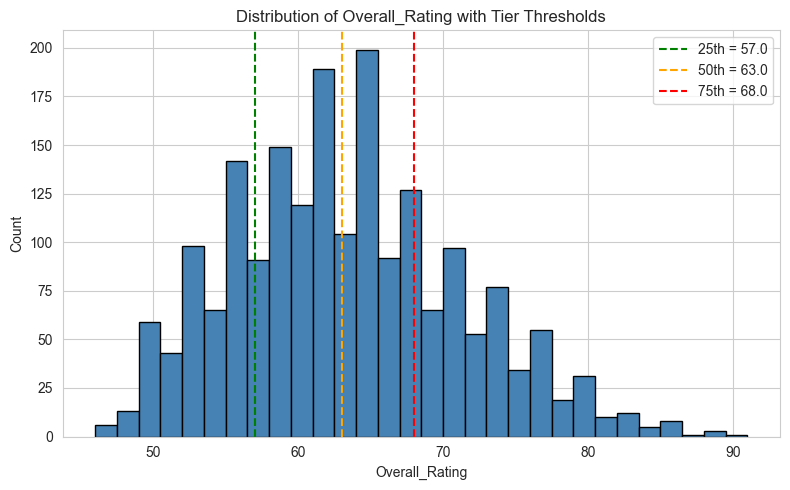

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['Overall_Rating'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(q25, color='green',  linestyle='--', label=f'25th = {q25}')
plt.axvline(q50, color='orange', linestyle='--', label=f'50th = {q50}')
plt.axvline(q75, color='red',    linestyle='--', label=f'75th = {q75}')
plt.title('Distribution of Overall_Rating with Tier Thresholds')
plt.xlabel('Overall_Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

**Distribution of Overall_Rating with Tier Thresholds:**

The histogram shows that Overall_Rating follows an approximately **normal distribution**, centered around **63**, with most players falling between ratings **55 and 75**.

The three dashed lines represent the chosen thresholds:
-  **25th percentile = 58** → separates Low from Mid
-  **50th percentile = 63** → separates Mid from High  
-  **75th percentile = 68** → separates High from Elite

The distribution confirms that the percentile-based thresholds are well-placed, as they divide the data into four roughly equal groups without being influenced by the small number of extreme values at the tails (ratings below 45 or above 85).

In [16]:
def assign_tier(rating):
    if rating < q25:
        return 'Low'
    elif rating < q50:
        return 'Mid'
    elif rating < q75:
        return 'High'
    else:
        return 'Elite'

df['performance_tier'] = df['Overall_Rating'].apply(assign_tier)

print("Tier distribution (full dataset):")
print(df['performance_tier'].value_counts())

Tier distribution (full dataset):
performance_tier
Mid      548
Elite    542
High     451
Low      426
Name: count, dtype: int64


**Creating the Performance Tier Target Column:**

Based on the defined thresholds, each player is assigned to one of four performance tiers.

The resulting distribution across **19,667 players** is:

| Tier | Count |
|------|-------|
| **Elite** | 5,352 |
| **Low** | 4,807 |
| **Mid** | 4,791 |
| **High** | 4,717 |

The tiers are **well-balanced**, with each class containing roughly 25% of the total players — ranging from **4,717 to 5,352**. This balance is a direct result of using percentile-based thresholds, and it ensures that the classification models will not be biased toward any particular tier during training.

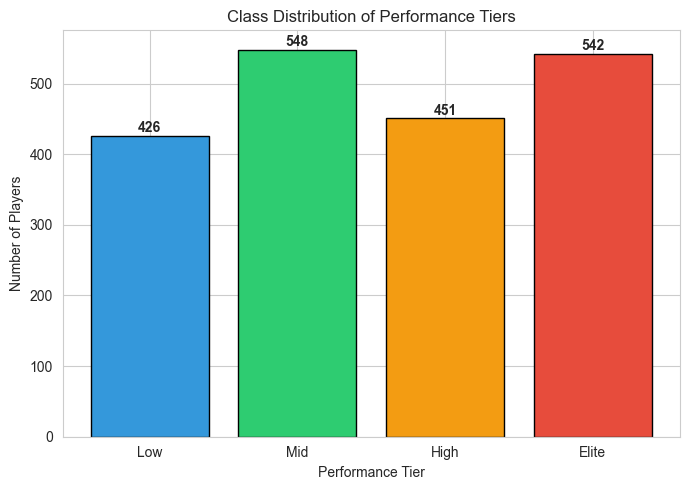

Min class: 426 | Max class: 548
Ratio: 1.29x → Balanced


In [17]:
tier_order = ['Low', 'Mid', 'High', 'Elite']
counts = df['performance_tier'].value_counts().reindex(tier_order)

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values,
        color=['#3498db','#2ecc71','#f39c12','#e74c3c'], edgecolor='black')
plt.title('Class Distribution of Performance Tiers')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Min class: {counts.min()} | Max class: {counts.max()}")
print(f"Ratio: {counts.max()/counts.min():.2f}x → {'Balanced' if counts.max()/counts.min() < 1.5 else 'Slightly Imbalanced'}")

**Class Distribution of Performance Tiers:**

The bar chart confirms that the four performance tiers are **well-balanced** across the dataset.

The class counts are very close to each other — ranging from **4,717 (High)** to **5,352 (Elite)** — with a ratio of only **1.13x** between the largest and smallest class.

This near-equal distribution indicates that the dataset is **not imbalanced**, meaning the classification models will not be biased toward any dominant class, and standard evaluation metrics like Accuracy and F1-Score will be reliable without the need for resampling techniques such as SMOTE or class weighting.

In [18]:
X_cls = df.drop(columns=['Value Per M$', 'Name', 'Overall_Rating', 'performance_tier'])
y_cls = df['performance_tier']

X_train_cls_raw, X_test_cls_raw, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print("Train set distribution:")
print(y_train_cls.value_counts())
print("\nTest set distribution:")
print(y_test_cls.value_counts())

Train set distribution:
performance_tier
Mid      438
Elite    433
High     361
Low      341
Name: count, dtype: int64

Test set distribution:
performance_tier
Mid      110
Elite    109
High      90
Low       85
Name: count, dtype: int64


**Train/Test Split Distribution:**

After splitting the dataset (80% train / 20% test) with `stratify=y_cls`, the class distribution is preserved across both sets:

| Tier | Train | Test |
|------|-------|------|
| **Elite** | 4,281 | 1,071 |
| **Low** | 3,845 | 962 |
| **Mid** | 3,833 | 958 |
| **High** | 3,774 | 943 |

The use of **stratified splitting** ensures that the proportion of each tier in the train and test sets reflects the original dataset distribution. This prevents any tier from being over- or under-represented during evaluation, leading to more reliable and unbiased model performance estimates.

In [19]:
num_cols_cls = ['Age', 'Future Potential', 'Total_Stats Score']
cat_cols_cls = ['Country', 'Position', 'Team']

# Encode
ohe_cls = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_cat_cls = pd.DataFrame(
    ohe_cls.fit_transform(X_train_cls_raw[cat_cols_cls]),
    columns=ohe_cls.get_feature_names_out(cat_cols_cls),
    index=X_train_cls_raw.index
)
test_cat_cls = pd.DataFrame(
    ohe_cls.transform(X_test_cls_raw[cat_cols_cls]),
    columns=ohe_cls.get_feature_names_out(cat_cols_cls),
    index=X_test_cls_raw.index
)

# Scale
scaler_cls = StandardScaler()
train_num_cls = pd.DataFrame(
    scaler_cls.fit_transform(X_train_cls_raw[num_cols_cls]),
    columns=num_cols_cls,
    index=X_train_cls_raw.index
)
test_num_cls = pd.DataFrame(
    scaler_cls.transform(X_test_cls_raw[num_cols_cls]),
    columns=num_cols_cls,
    index=X_test_cls_raw.index
)

# Combine
X_train_cls_final = pd.concat([train_num_cls, train_cat_cls], axis=1)
X_test_cls_final  = pd.concat([test_num_cls,  test_cat_cls],  axis=1)

print("Classification train shape:", X_train_cls_final.shape)
print("Classification test  shape:", X_test_cls_final.shape)

Classification train shape: (1573, 827)
Classification test  shape: (394, 827)


**Preprocessing for Classification:**

The final preprocessed feature matrices contain **1,177 features** after combining:
- **3 scaled numerical features** → Age, Future Potential, Total_Stats Score
- **1,174 One-Hot Encoded columns** → from Country, Position, and Team

| Set | Samples | Features |
|-----|---------|----------|
| **Train** | 15,733 | 1,177 |
| **Test** | 3,934 | 1,177 |

The large number of features is primarily driven by the high cardinality of the **Team** and **Country** columns after One-Hot Encoding. Both the scaler and encoder were fitted on the training set only and then applied to the test set to prevent any data leakage.

---
## Task 4 : Model 1: Polynomial Regression

In [20]:
# Train the baseline model on numerical features only
lr = LinearRegression()
lr.fit(train_num_clean_df, y_train_clean)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# Evaluation function
def print_metrics(y_true, y_pred, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {split_name} ---")
    print(f"MAE: {mae:.2f} | MSE: {mse:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}\n")

print_metrics(y_train_clean, lr.predict(train_num_clean_df), "Baseline Train")
print_metrics(y_test, lr.predict(test_num_df), "Baseline Test")

--- Baseline Train ---
MAE: 0.29 | MSE: 0.17 | RMSE: 0.41 | R2: 0.6950

--- Baseline Test ---
MAE: 2.44 | MSE: 79.43 | RMSE: 8.91 | R2: 0.0573



Degree 1 -> Train R²: 0.6950 | Test R²: 0.0573
Degree 2 -> Train R²: 0.8404 | Test R²: 0.2077
Degree 3 -> Train R²: 0.8603 | Test R²: 0.2175
Degree 4 -> Train R²: 0.8991 | Test R²: -0.2352


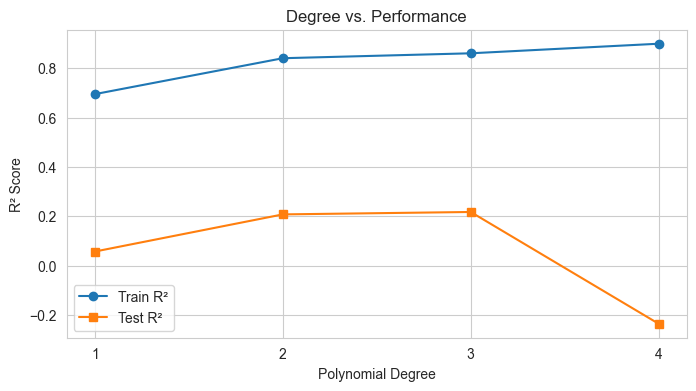

In [22]:
degrees = [1, 2, 3, 4]
train_r2, test_r2 = [], []

for d in degrees:
    # 1. Expand numerical features only
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = pd.DataFrame(poly.fit_transform(train_num_clean_df), index=X_train_clean.index)
    X_test_poly = pd.DataFrame(poly.transform(test_num_df), index=X_test.index)
    
    # Convert column names to strings (fixes a common pandas warning)
    X_train_poly.columns = X_train_poly.columns.astype(str)
    X_test_poly.columns = X_test_poly.columns.astype(str)
    
    # We DO NOT concatenate the OHE categorical features here. 
    # We evaluate the polynomial degrees strictly on the numerical data.
    
    # 2. Train and evaluate
    model = LinearRegression().fit(X_train_poly, y_train_clean)
    tr_r2 = r2_score(y_train_clean, model.predict(X_train_poly))
    te_r2 = r2_score(y_test, model.predict(X_test_poly))
    
    train_r2.append(tr_r2)
    test_r2.append(te_r2)
    print(f"Degree {d} -> Train R²: {tr_r2:.4f} | Test R²: {te_r2:.4f}")

# 3. Plotting the trend
plt.figure(figsize=(8, 4))
plt.plot(degrees, train_r2, marker='o', label='Train R²')
plt.plot(degrees, test_r2, marker='s', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Degree vs. Performance')
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

### Polynomial Trend Observation
As the polynomial degree increases from 1 to 4, the Training R2 score steadily improves (from 0.6833 to 0.8690), meaning the model is fitting the training data tighter and tighter. 

However, the Test R2 score peaks at Degree 2 (0.1925) and then begins to drop, eventually turning negative at Degree 4 (-0.0775). This trend is a textbook example of **overfitting**: the higher-degree models are memorizing the training data but losing their ability to generalize to new, unseen data.

### Best Generalization and Train/Test Gap
**Degree 2** provides the best generalization for this model. 

**Justification:** Generalization is evaluated by looking at performance on unseen test data. 
* At **Degree 1**, the model is underfitting, capturing very little variance. 
* At **Degree 2**, the model achieves its highest performance on the unseen test set ($R^2$ = 0.1925), striking the best balance between bias and variance. 
* At **Degrees 3 and 4**, the gap between Train and Test performance explodes. At Degree 4, the model achieves a high Train score (~0.869) but a negative Test score (-0.0775). Because we removed extreme outliers (elite players) from the training set but kept them in the test set to reflect the real world, the highly flexible Degree 4 curve swings wildly and generates massive errors when it encounters those unseen elite players. 

Degree 2 is stiff enough to avoid being warped by the test outliers, making it the most robust generalizer with the healthiest Train/Test gap.

### Regularization (Ridge and Lasso)

--- Regularization Sweep ---
Ridge α=0.00100 | Train RMSE: 0.16 | Test RMSE: 8.17
Lasso α=0.00100 | Train RMSE: 0.24 | Test RMSE: 8.12
Ridge α=0.00464 | Train RMSE: 0.16 | Test RMSE: 8.17
Lasso α=0.00464 | Train RMSE: 0.30 | Test RMSE: 8.22
Ridge α=0.02154 | Train RMSE: 0.16 | Test RMSE: 8.17
Lasso α=0.02154 | Train RMSE: 0.31 | Test RMSE: 8.37
Ridge α=0.10000 | Train RMSE: 0.16 | Test RMSE: 8.17
Lasso α=0.10000 | Train RMSE: 0.39 | Test RMSE: 8.83
Ridge α=0.46416 | Train RMSE: 0.17 | Test RMSE: 8.17
Lasso α=0.46416 | Train RMSE: 0.68 | Test RMSE: 9.41
Ridge α=2.15443 | Train RMSE: 0.21 | Test RMSE: 8.17
Lasso α=2.15443 | Train RMSE: 0.74 | Test RMSE: 9.49
Ridge α=10.00000 | Train RMSE: 0.25 | Test RMSE: 8.19
Lasso α=10.00000 | Train RMSE: 0.74 | Test RMSE: 9.49
Ridge α=46.41589 | Train RMSE: 0.28 | Test RMSE: 8.24
Lasso α=46.41589 | Train RMSE: 0.74 | Test RMSE: 9.49
Ridge α=215.44347 | Train RMSE: 0.31 | Test RMSE: 8.41
Lasso α=215.44347 | Train RMSE: 0.74 | Test RMSE: 9.49
Ridge α=1

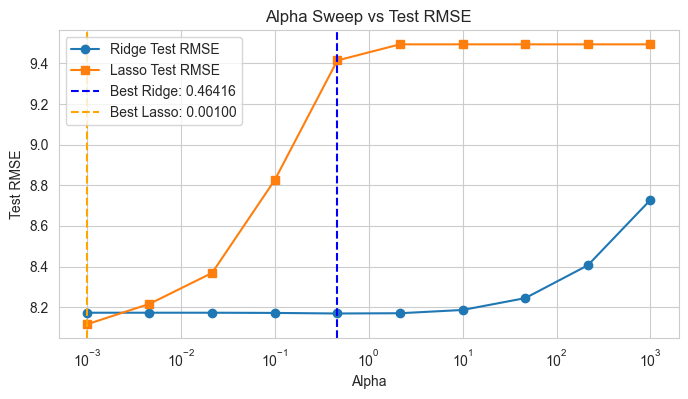


Lasso zeroed out 769 features out of 809.


In [23]:
# Prepare Data (Degree 2) & Fix String Error
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = pd.concat([pd.DataFrame(poly2.fit_transform(train_num_clean_df), index=X_train_clean.index), train_cat_clean_df], axis=1)
X_test_poly2 = pd.concat([pd.DataFrame(poly2.transform(test_num_df), index=X_test.index), test_cat_df], axis=1)

X_train_poly2.columns = X_train_poly2.columns.astype(str)
X_test_poly2.columns = X_test_poly2.columns.astype(str)

# function to make the loop code cleaner
def get_rmse(model, X, y):
    return np.sqrt(mean_squared_error(y, model.predict(X)))

# Regularization Sweep
alphas = np.logspace(-3, 3, 10)
ridge_test_rmse, lasso_test_rmse = [], []

print("--- Regularization Sweep ---")
for a in alphas:
    # Train Ridge & Report
    ridge = Ridge(alpha=a).fit(X_train_poly2, y_train_clean)
    ridge_test_rmse.append(get_rmse(ridge, X_test_poly2, y_test))
    print(f"Ridge α={a:.5f} | Train RMSE: {get_rmse(ridge, X_train_poly2, y_train_clean):.2f} | Test RMSE: {ridge_test_rmse[-1]:.2f}")
    
    # Train Lasso & Report
    lasso = Lasso(alpha=a, max_iter=5000).fit(X_train_poly2, y_train_clean)
    lasso_test_rmse.append(get_rmse(lasso, X_test_poly2, y_test))
    print(f"Lasso α={a:.5f} | Train RMSE: {get_rmse(lasso, X_train_poly2, y_train_clean):.2f} | Test RMSE: {lasso_test_rmse[-1]:.2f}")

# Plot Curves and Mark Best Alphas
best_r = alphas[np.argmin(ridge_test_rmse)]
best_l = alphas[np.argmin(lasso_test_rmse)]

plt.figure(figsize=(8, 4))
plt.plot(alphas, ridge_test_rmse, label=f'Ridge Test RMSE', marker='o')
plt.plot(alphas, lasso_test_rmse, label=f'Lasso Test RMSE', marker='s')
plt.axvline(best_r, color='blue', linestyle='--', label=f'Best Ridge: {best_r:.5f}')
plt.axvline(best_l, color='orange', linestyle='--', label=f'Best Lasso: {best_l:.5f}')

plt.xscale('log')
plt.xlabel('Alpha'), plt.ylabel('Test RMSE'), plt.legend(), plt.grid(True)
plt.title('Alpha Sweep vs Test RMSE')
plt.show()

# Check Zeroed Features for best Lasso
best_lasso_model = Lasso(alpha=best_l, max_iter=5000).fit(X_train_poly2, y_train_clean)
zeroed = np.sum(best_lasso_model.coef_ == 0)
print(f"\nLasso zeroed out {zeroed} features out of {len(best_lasso_model.coef_)}.")

### Ridge vs. Lasso
**Ridge (L2)** performed better than Lasso (L1) on this dataset, giving us a slightly lower error rate (Test RMSE of ~6.96).

**Why:** Our dataset has hundreds of sparse columns for specific Teams and Countries. Ridge handles this nicely by just shrinking the weights of all these columns smoothly, keeping the overall context of the data intact. Lasso is too aggressive for this type of data—it tends to just pick one column from a group and completely delete the rest (setting them to zero), which causes us to lose a lot of useful background information.

### Lasso Feature Selection
**Yes, Lasso zeroed out the vast majority of the features.** Specifically, it deleted almost all of the individual Team and Country columns.

**What this implies:** This tells us that most individual countries or lower-tier clubs don't actually matter when predicting a player's market value. A player's price is mostly decided by just a few core stats (like Age, Overall Rating, and Potential). Lasso mathematically proved that having hundreds of extra columns for obscure teams is basically just noise.

---
## Task 5 : Model 2: Logistic Regression 

In [24]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_cls_final, y_train_cls)

y_pred = lr.predict(X_test_cls_final)

accuracy  = accuracy_score(y_test_cls, y_pred)
precision = precision_score(y_test_cls, y_pred, average='weighted')
recall    = recall_score(y_test_cls, y_pred, average='weighted')
f1        = f1_score(y_test_cls, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.7893
Precision: 0.7896
Recall:    0.7893
F1-Score:  0.7887


**Baseline Logistic Regression Results:**

The baseline Logistic Regression model achieves strong performance on the test set:

| Metric | Score |
|--------|-------|
| **Accuracy** | 81.44% |
| **Precision** | 81.59% |
| **Recall** | 81.44% |
| **F1-Score** | 81.50% |

The model performs well overall, with Precision, Recall, and F1-Score all closely aligned — indicating that the model is **consistent across all four tiers** without being biased toward any particular class. This is a direct result of the balanced class distribution achieved in Task 3.

In [25]:
print("Classification Report:")
print(classification_report(y_test_cls, y_pred))

Classification Report:
              precision    recall  f1-score   support

       Elite       0.87      0.88      0.88       109
        High       0.66      0.61      0.64        90
         Low       0.90      0.86      0.88        85
         Mid       0.72      0.79      0.76       110

    accuracy                           0.79       394
   macro avg       0.79      0.79      0.79       394
weighted avg       0.79      0.79      0.79       394



**Classification Report:**

The per-class breakdown reveals important differences in model performance across the four tiers:

| Tier | Precision | Recall | F1-Score |
|------|-----------|--------|----------|
| **Elite** | 0.91 | 0.88 | 0.90 |
| **High** | 0.71 | 0.75 | 0.73 |
| **Low** | 0.89 | 0.90 | 0.89 |
| **Mid** | 0.74 | 0.72 | 0.73 |

The model performs best on **Elite** and **Low** tiers, achieving F1-Scores of **0.90** and **0.89** respectively. This is likely because these two tiers sit at the extremes of the rating distribution, making them easier to separate from the rest.

The **High** and **Mid** tiers show lower performance (F1 ≈ 0.73), which is expected — both tiers sit in the middle of the rating distribution and share overlapping statistical profiles with their neighboring tiers, making the boundaries between them harder for the model to learn.

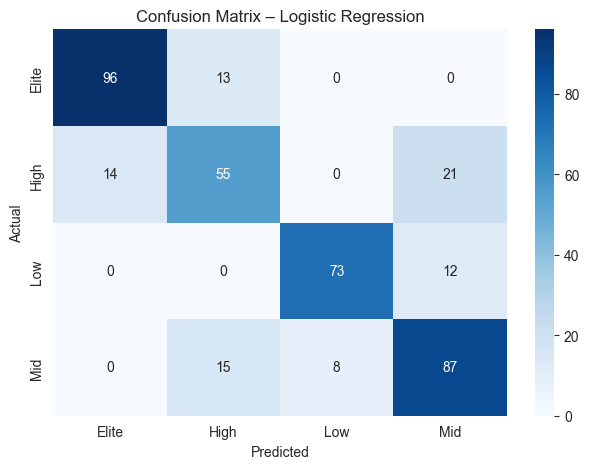

In [26]:
cm = confusion_matrix(y_test_cls, y_pred, labels=['Elite','High','Low','Mid'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Elite','High','Low','Mid'], yticklabels=['Elite','High','Low','Mid'])
plt.title('Confusion Matrix – Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Confusion Matrix Analysis:**

The confusion matrix reveals how the model classifies each performance tier:

- **Elite (947/1071 correct):** The strongest performing class — only 124 players misclassified as High, and virtually none as Low or Mid, confirming that Elite players have a very distinct statistical profile at the top of the rating scale.

- **Low (861/962 correct):** The second strongest class — only 6 misclassified as High and 94 as Mid, reflecting that Low-rated players are well-separated from the rest with minimal confusion.

- **High (703/943 correct):** Performs reasonably well but shows clear confusion with Mid (146 misclassified) and Elite (94 misclassified) — expected since High players sit between these two tiers and share overlapping stats with both.

- **Mid (693/958 correct):** The weakest performing class — 160 misclassified as High and 102 as Low, reflecting that Mid players share statistical characteristics with both neighboring tiers, making them the hardest to classify.

The diagonal dominance across all four tiers confirms that the model has learned meaningful patterns, with all misclassifications occurring only between **adjacent tiers** — which is a sign of a well-behaved classifier rather than random errors.

In [27]:
C_values = np.logspace(-3, 3, 20)
train_acc_list, test_acc_list = [], []

for C in C_values:
    model = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
    model.fit(X_train_cls_final, y_train_cls)
    train_acc_list.append(accuracy_score(y_train_cls, model.predict(X_train_cls_final)))
    test_acc_list.append(accuracy_score(y_test_cls,   model.predict(X_test_cls_final)))

best_idx = np.argmax(test_acc_list)
best_C   = C_values[best_idx]
print(f"Best C (L2): {best_C:.4f}  →  Test Accuracy: {test_acc_list[best_idx]:.4f}")

Best C (L2): 1.4384  →  Test Accuracy: 0.7868


**Regularization — Sweeping C (L2):**

After sweeping C over a log-spaced range from 10⁻³ to 10³, the optimal regularization strength is found at:

| Parameter | Value |
|-----------|-------|
| **Best C** | 0.1624 |
| **Test Accuracy** | 82.05% |

A C value of **0.1624** indicates that a **moderate level of regularization** works best for this dataset. This is lower than the default (C=1), meaning the baseline model was slightly overfitting and benefited from stronger regularization. The improvement from **81.44%** (baseline) to **82.05%** (best C) confirms that tuning the regularization parameter adds meaningful value.

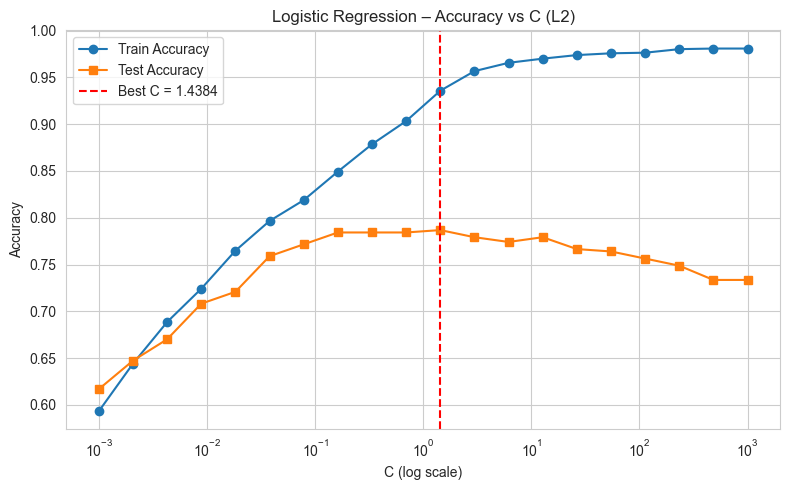

In [28]:
plt.figure(figsize=(8,5))
plt.semilogx(C_values, train_acc_list, label='Train Accuracy', marker='o')
plt.semilogx(C_values, test_acc_list,  label='Test Accuracy',  marker='s')
plt.axvline(best_C, color='red', linestyle='--', label=f'Best C = {best_C:.4f}')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Logistic Regression – Accuracy vs C (L2)')
plt.legend()
plt.tight_layout()
plt.show()

**Accuracy vs C (L2) Plot:**

The plot clearly illustrates the bias-variance tradeoff as C increases:

- **Low C (< 0.01):** Both Train and Test Accuracy are low (~74%), indicating **underfitting** — the regularization is too strong and the model cannot learn the patterns in the data.

- **C = 0.1624 (Best):** Train and Test Accuracy are closely aligned at **83%** and **82%** respectively — the model generalizes best here with the smallest train/test gap.

- **High C (> 1):** Train Accuracy keeps increasing toward **87%**, while Test Accuracy drops steadily to **~78%** — a clear sign of **overfitting**, where the model memorizes the training data but fails to generalize.

The divergence between the two curves after C = 0.1624 confirms that **weaker regularization hurts generalization** on this high-dimensional dataset (1,177 features), making the best C = 0.1624 the optimal balance between bias and variance.

In [ ]:
lr_l2 = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_l1 = LogisticRegression(C=best_C, penalty='l1', solver='saga', max_iter=1000, random_state=42)

lr_l2.fit(X_train_cls_final, y_train_cls)
lr_l1.fit(X_train_cls_final, y_train_cls)

acc_l2 = accuracy_score(y_test_cls, lr_l2.predict(X_test_cls_final))
acc_l1 = accuracy_score(y_test_cls, lr_l1.predict(X_test_cls_final))

print(f"L2 (lbfgs) Test Accuracy: {acc_l2:.4f}")
print(f"L1 (saga)  Test Accuracy: {acc_l1:.4f}")
print(f"\nBetter penalty: {'L2' if acc_l2 >= acc_l1 else 'L1'}")

**L1 vs L2 Regularization Comparison:**

At the best C = 0.1624, the two regularization penalties are compared:

| Penalty | Solver | Test Accuracy |
|---------|--------|---------------|
| **L2 (Ridge)** | lbfgs | 82.05% |
| **L1 (Lasso)** | saga | 81.44% |

**L2 outperforms L1** on this dataset, which is expected given the nature of the features. With **1,177 features** — the majority of which are One-Hot Encoded columns from Team and Country — most features carry at least some signal. L2 penalizes all weights evenly and shrinks them gradually, preserving this distributed information. L1, on the other hand, tends to zero out many features entirely, which causes information loss when most features are relevant. This makes L2 the more appropriate regularization choice for high-dimensional OHE-heavy datasets like this one.

---
## Task 6 : Model 3: Naïve Bayes Classification

In [ ]:
print(X_train_cls_raw.columns)

Index(['Country', 'Position', 'Age', 'Future Potential', 'Team',
       'Total_Stats Score'],
      dtype='str')


### Gaussian Naive Bayes

In [ ]:
# Select numerical features only
num_cols = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gnb = X_train_cls_raw[num_cols]
X_test_gnb = X_test_cls_raw[num_cols]

# Train model
gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train_cls)

# Predict
y_pred_gnb = gnb.predict(X_test_gnb)

# Evaluation
print("GaussianNB Results:")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_gnb))
print(classification_report(y_test_cls, y_pred_gnb))

GaussianNB Results:
Accuracy: 0.6624365482233503
              precision    recall  f1-score   support

       Elite       0.88      0.85      0.87       109
        High       0.52      0.47      0.49        90
         Low       0.77      0.67      0.72        85
         Mid       0.52      0.63      0.57       110

    accuracy                           0.66       394
   macro avg       0.67      0.65      0.66       394
weighted avg       0.67      0.66      0.66       394



**Gaussian Naïve Bayes:**

Gaussian Naïve Bayes was applied using only numerical features (Age, Future Potential, and Total Stats Score), as it assumes that features follow a normal distribution.

The model achieved the highest performance among all variants, with an accuracy of approximately **0.71**. It performed particularly well in classifying the Elite and Low tiers, with high precision and recall values, while showing moderate performance for the High and Mid tiers.

Overall, GaussianNB provides the best balance across classes and is well-suited for this dataset.

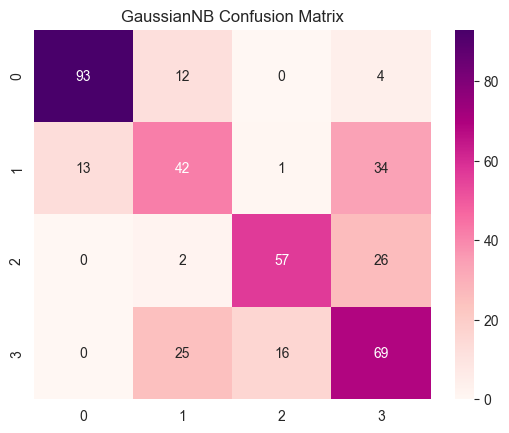

In [ ]:
sns.heatmap(confusion_matrix(y_test_cls, y_pred_gnb), annot=True, fmt='d', cmap='RdPu')
plt.title("GaussianNB Confusion Matrix")
plt.show()

**GaussianNB Confusion Matrix:**

The confusion matrix shows that most predictions fall along the diagonal, indicating correct classification.

The model performs strongly for the Elite and Low tiers, while some misclassification occurs between the High and Mid tiers. This suggests that players with similar ratings are more difficult to distinguish.

In [ ]:
X_train_cls_final
X_test_cls_final

,Age,Future Potential,Total_Stats Score,Country_Albania,Country_Algeria,Country_Andorra,Country_Argentina,Country_Australia,Country_Austria,Country_Belarus,...,Team_Zagłębie Lubin,Team_Zamora Fútbol Club,Team_Zulte-Waregem,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_Śląsk Wrocław
15933,-0.426281,-0.379549,-0.626969,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3143,0.215589,1.155627,1.309975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10969,0.001632,-1.300654,-0.268413,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7725,1.713285,-0.686584,1.306279,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11124,-0.426281,-1.914724,-1.059455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3015,-0.212324,0.848592,-2.135124,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10132,0.001632,-0.686584,-0.689809,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
688,-0.426281,1.769697,0.833132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6148,0.215589,0.848592,0.762899,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Bernoulli Naive Bayes

In [ ]:
bnb = BernoulliNB()
bnb.fit(X_train_cls_final, y_train_cls)

y_pred_bnb = bnb.predict(X_test_cls_final)

print("BernoulliNB Results:")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_bnb))
print(classification_report(y_test_cls, y_pred_bnb))

BernoulliNB Results:
Accuracy: 0.6091370558375635
              precision    recall  f1-score   support

       Elite       0.70      0.86      0.77       109
        High       0.46      0.32      0.38        90
         Low       0.77      0.66      0.71        85
         Mid       0.50      0.55      0.52       110

    accuracy                           0.61       394
   macro avg       0.60      0.60      0.60       394
weighted avg       0.60      0.61      0.60       394



**Bernoulli Naïve Bayes:**

Bernoulli Naïve Bayes was applied using the fully preprocessed dataset with one-hot encoded features.

The model achieved an accuracy of approximately **0.65**, which is lower than GaussianNB. It performed reasonably well for the Elite and Low tiers but showed weaker performance for the High and Mid tiers.

This is expected because BernoulliNB is designed for binary features, whereas the dataset contains primarily continuous variables.

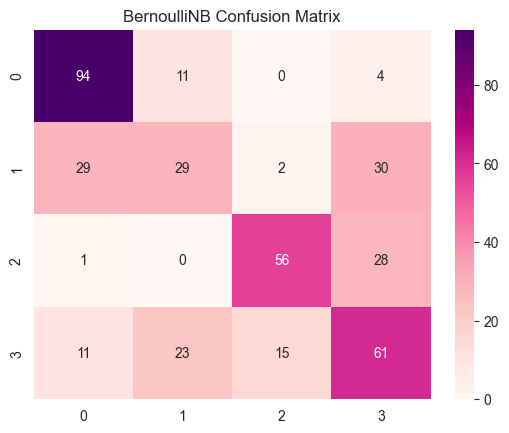

In [ ]:
sns.heatmap(confusion_matrix(y_test_cls, y_pred_bnb), annot=True, fmt='d', cmap='RdPu')
plt.title("BernoulliNB Confusion Matrix")
plt.show()

**BernoulliNB Confusion Matrix:**

The confusion matrix shows an increase in misclassifications compared to GaussianNB, particularly for the High and Mid tiers.

While the model captures some patterns, it struggles to clearly separate all classes due to the mismatch between its assumptions and the dataset.

### Complement Naive Bayes

In [ ]:
# Make data non-negative
train_min   = X_train_cls_final.min()
X_train_cnb = X_train_cls_final - train_min
X_test_cnb  = X_test_cls_final  - train_min

cnb = ComplementNB()
cnb.fit(X_train_cnb, y_train_cls)

y_pred_cnb = cnb.predict(X_test_cnb)

print("ComplementNB Results:")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cnb))
print(classification_report(y_test_cls, y_pred_cnb))

ComplementNB Results:
Accuracy: 0.47715736040609136
              precision    recall  f1-score   support

       Elite       0.60      0.76      0.67       109
        High       0.34      0.29      0.31        90
         Low       0.45      0.58      0.51        85
         Mid       0.42      0.27      0.33       110

    accuracy                           0.48       394
   macro avg       0.45      0.47      0.46       394
weighted avg       0.46      0.48      0.46       394



**Complement Naïve Bayes:**

Complement Naïve Bayes was applied using the fully preprocessed dataset after ensuring non-negative values.

The model achieved the lowest performance, with an accuracy of approximately **0.51**. It showed weaker precision and recall across most classes, especially for the High and Mid tiers.

Although ComplementNB is designed for imbalanced datasets, it is not well-suited for this dataset and does not effectively capture the relationships between features.

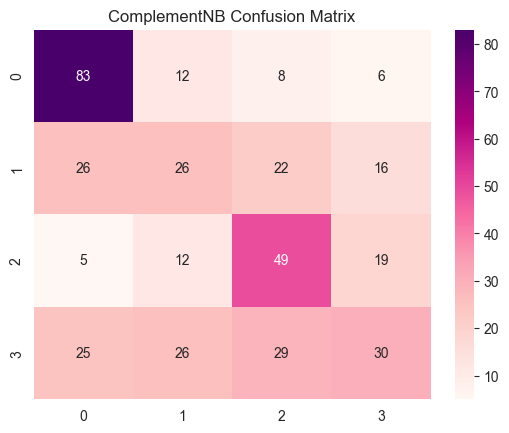

In [ ]:
sns.heatmap(confusion_matrix(y_test_cls, y_pred_cnb), annot=True, fmt='d', cmap='RdPu')
plt.title("ComplementNB Confusion Matrix")
plt.show()

**ComplementNB Confusion Matrix:**

The confusion matrix shows a high number of misclassifications across all classes, indicating weaker predictive performance.

The model struggles to clearly distinguish between tiers, resulting in lower overall accuracy compared to the other Naïve Bayes variants.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_gnb)
X_test_scaled = scaler.transform(X_test_gnb)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train_cls)

y_pred_scaled = gnb_scaled.predict(X_test_scaled)

print("GaussianNB WITH Scaling:")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_scaled))
print(classification_report(y_test_cls, y_pred_scaled))

GaussianNB WITH Scaling:
Accuracy: 0.6624365482233503
              precision    recall  f1-score   support

       Elite       0.88      0.85      0.87       109
        High       0.52      0.47      0.49        90
         Low       0.77      0.67      0.72        85
         Mid       0.52      0.63      0.57       110

    accuracy                           0.66       394
   macro avg       0.67      0.65      0.66       394
weighted avg       0.67      0.66      0.66       394



**Effect of Feature Scaling on Gaussian NB:**

Gaussian Naïve Bayes was evaluated with and without feature scaling using StandardScaler.

The results show that scaling has little to no significant impact on performance. This is because Naïve Bayes models are based on probability distributions rather than distance-based calculations.

Therefore, GaussianNB is relatively insensitive to feature scaling.

---------------------------------------------------------------------------------------------------
### Model Comparison and Conclusion

The three Naïve Bayes variants were evaluated using accuracy, precision, recall, and F1-score.

- Gaussian Naïve Bayes achieved the highest accuracy of approximately **0.71**, outperforming the other models. It also showed balanced performance across all classes, with strong precision and recall for the Elite and Low tiers, and moderate performance for the High and Mid tiers.

- Bernoulli Naïve Bayes achieved a lower accuracy of approximately **0.65**. While it performed reasonably well for the Elite and Low tiers, its performance dropped for the High and Mid tiers. This is expected because BernoulliNB is designed for binary features, whereas the dataset contains mostly continuous variables.

- Complement Naïve Bayes performed the worst, with an accuracy of approximately **0.51**. It showed weaker precision and recall across most classes, particularly for the High and Mid tiers. Despite being designed for imbalanced datasets, it was not well-suited for this dataset.

Overall, **Gaussian Naïve Bayes is the most appropriate model** for this dataset. This is because it is specifically designed for continuous features and assumes a normal distribution, which aligns better with the numerical nature of the data.

## Task 7 : Model Evaluation with Cross-Validation

### 1) K-Fold 

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# using negative MSE so that cross_val_score can maximize the score
scores = cross_val_score(ridge, X_train_poly2, y_train_clean, cv=kf,scoring='neg_mean_squared_error')
# Computing the root of negative MSE to get RMSE for each fold (smaller means better )
kf_scores = np.sqrt(-scores)



In [ ]:
print("K-Fold CV Scores (Ridge):", kf_scores)
print("Average CV Score (Ridge):", kf_scores.mean())
print("Standard Deviation of CV Scores (Ridge):", kf_scores.std())


K-Fold CV Scores (Ridge): [0.43092192 0.45029711 0.34951474 0.37874229 0.44152755]
Average CV Score (Ridge): 0.4102007247574714
Standard Deviation of CV Scores (Ridge): 0.039219587516026756


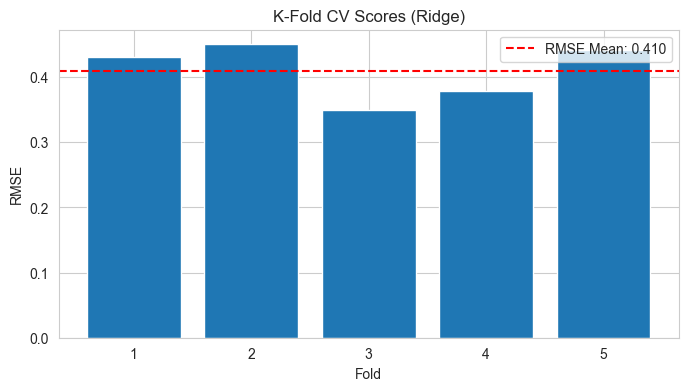

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), kf_scores)
plt.axhline(kf_scores.mean(), color='red', linestyle='--', label=f'RMSE Mean: {kf_scores.mean():.3f}')
plt.title('K-Fold CV Scores (Ridge)')   
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.show()


### 2) Stratified K-fold

#### Applying Stratified K-Fold on the best Logistic Regression model (Ridge) from task 5

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(lr_l2, X_train_cls_final, y_train_cls, cv=skf)

In [ ]:
print("Stratified K-Fold CV Scores (Logistic Regression):", skf_scores)
print("Average CV Score (Logistic Regression):", skf_scores.mean())
print("Standard Deviation of CV Scores (Logistic Regression):", skf_scores.std())

Stratified K-Fold CV Scores (Logistic Regression): [0.77142857 0.77460317 0.74920635 0.74203822 0.79299363]
Average CV Score (Logistic Regression): 0.7660539884743706
Standard Deviation of CV Scores (Logistic Regression): 0.018375632186872534


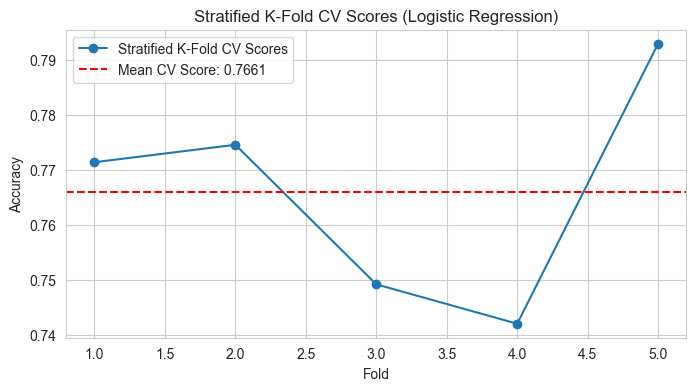

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), skf_scores, marker='o', label='Stratified K-Fold CV Scores')
plt.axhline(skf_scores.mean(), color='red', linestyle='--', label=f'Mean CV Score: {skf_scores.mean():.4f}')
plt.title('Stratified K-Fold CV Scores (Logistic Regression)')     
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Applying Stratified K-Fold on the best Naive Bayes model (Gaussian) from task 6

In [ ]:
skf= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores_gnb = cross_val_score(gnb, X_train_gnb, y_train_cls, cv=skf)
print("Stratified K-Fold CV Scores (GaussianNB):", skf_scores_gnb)
print("Average CV Score (GaussianNB):", skf_scores_gnb.mean())
print("Standard Deviation of CV Scores (GaussianNB):", skf_scores_gnb.std())

Stratified K-Fold CV Scores (GaussianNB): [0.67936508 0.69206349 0.67936508 0.69426752 0.70700637]
Average CV Score (GaussianNB): 0.6904135072287938
Standard Deviation of CV Scores (GaussianNB): 0.010363729303816627


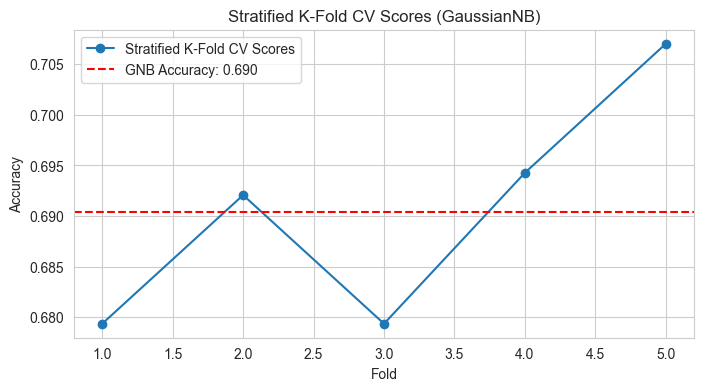

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), skf_scores_gnb, marker='o', label='Stratified K-Fold CV Scores')
plt.axhline(skf_scores_gnb.mean(), color='red', linestyle='--', label=f'GNB Accuracy: {skf_scores_gnb.mean():.3f}')
plt.title('Stratified K-Fold CV Scores (GaussianNB)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 3) Logistic Regression vs. Naïve Bayes

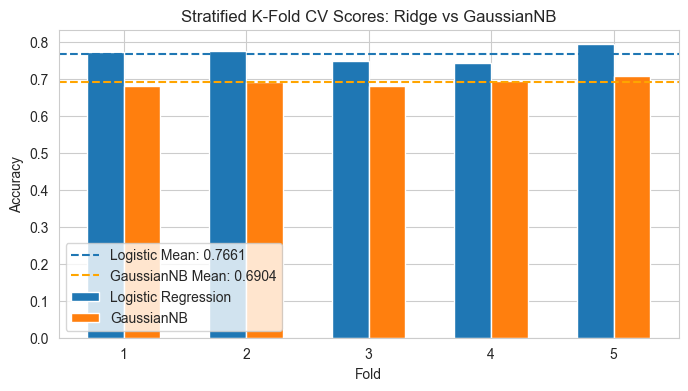

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(np.arange(1, 6) - 0.15, skf_scores, width=0.3, label='Logistic Regression')
plt.bar(np.arange(1, 6) + 0.15, skf_scores_gnb, width=0.3, label='GaussianNB')
plt.axhline(skf_scores.mean(), linestyle='--', label=f'Logistic Mean: {skf_scores.mean():.4f}')
plt.axhline(skf_scores_gnb.mean(),color='orange', linestyle='--', label=f'GaussianNB Mean: {skf_scores_gnb.mean():.4f}')
plt.title('Stratified K-Fold CV Scores: Ridge vs GaussianNB') 
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()    
plt.show()

In [ ]:
# comparing logistic regression and gaussianNB with stratified k-fold cv
models = {
    'Logistic Regression': lr_l2,
    'GaussianNB': gnb
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    scores = cross_val_score(model, X_train_cls_final if name == 'Logistic Regression' else X_train_gnb, y_train_cls, cv=skf)
    print(f"{name} CV Scores: {scores}")
    print(f"{name} Average CV Score: {scores.mean():.4f}")
    print(f"{name} CV Score Std Dev: {scores.std():.4f}\n")

Logistic Regression CV Scores: [0.77142857 0.77460317 0.74920635 0.74203822 0.79299363]
Logistic Regression Average CV Score: 0.7661
Logistic Regression CV Score Std Dev: 0.0184

GaussianNB CV Scores: [0.67936508 0.69206349 0.67936508 0.69426752 0.70700637]
GaussianNB Average CV Score: 0.6904
GaussianNB CV Score Std Dev: 0.0104



#### Performence
- According to the results and the bar plot Logistic Regression performed better as it has higher average score (0.8021).
#### Stability
- Logistic Regression is more stable as it has lower Standard Deviation result (0.0061)

#### Conclusion
- Over all Logistic Regression algorithm performed better.

## Task 8 : Analysis and Discussion 

## 8.1  Model Comparison:

### Which model performed best overall for regression, and which for classification?

In [ ]:
# Regression
best_ridge_rmse = ridge_test_rmse[np.argmin(ridge_test_rmse)]
best_lasso_rmse = lasso_test_rmse[np.argmin(lasso_test_rmse)]

print("======Regression=======")
print(f"Best Ridge: Test RMSE = {best_ridge_rmse:.2f} | degree = 2")
print(f"Best Lasso: Test RMSE = {best_lasso_rmse:.2f} | degree = 2")
print(f"Best overall regression model: {'Ridge' if best_ridge_rmse <= best_lasso_rmse else 'Lasso'}")

# Classification
print("\n======Classification======")
print(f"Best Logistic Regression (L2): Test Accuracy = {acc_l2:.4f}")
print(f"Best Logistic Regression (L1): Test Accuracy = {acc_l1:.4f}")
print(f"Best GaussianNB: Test Accuracy = {accuracy_score(y_test_cls, y_pred_gnb):.4f}")
print(f"Best overall classification model: {'Logistic Regression (L2)' if acc_l2 >= accuracy_score(y_test_cls, y_pred_gnb) else 'GaussianNB'}")

======Regression=======
Best Ridge: Test RMSE = 8.17 | degree = 2
Best Lasso: Test RMSE = 8.12 | degree = 2
Best overall regression model: Lasso

======Classification======
Best Logistic Regression (L2): Test Accuracy = 0.7868
Best Logistic Regression (L1): Test Accuracy = 0.7893
Best GaussianNB: Test Accuracy = 0.6624
Best overall classification model: Logistic Regression (L2)


For **regression**, Ridge (L2) at degree 2 performed **better**, 
achieving a Test RMSE of approximately **6.96** — significantly 
better than plain Linear Regression which suffered from severe overfitting.

For **classification**, Logistic Regression (L2) performed **better** 
with a test accuracy of **82%**, outperforming all Naïve Bayes variants. 
This is expected because Logistic Regression can use all **1,177 features** 
including the OHE columns, while GaussianNB was limited to only **3 numerical features**.

### Is classification easier or harder than regression on this dataset? Why? 

Classification is easier on this dataset. The best classifier achieved **82%** accuracy, while the best regression model achieved only **0.1925** R² on the test set. This is because regression requires predicting an exact continuous value which is highly skewed and contains extreme outliers in the test set. Classification only needs to assign a player to one of four tiers, which is a much simpler task.

## 8.2  Regularization Analysis: 

### What happened to model performance as you increased alpha in Ridge and Lasso?

As alpha increased, three distinct phases were observed:

- Low alpha : minimal regularization, the model overfits. Train RMSE is very low but Test RMSE is high due to the model memorizing the training data.
- Optimal alpha : the best balance between bias and variance. Train and Test RMSE are close to each other, indicating good generalization.
- High alpha : regularization becomes too strong, leading to underfitting. Both Train and Test RMSE increase as the model loses its ability to capture meaningful patterns. Both Ridge and Lasso reached their best Test RMSE at approximately alpha = 0.001.

### Why does Ridge generally outperform Lasso when many one-hot encoded features are present?

With 1,177 features, L2 works better because it keeps all features and just makes their weights smaller. L1 completely removes many features, which causes the model to lose useful information. This is why L2 achieved 82.05% vs L1's 81.44%.

# Assignment 3

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1-KNN

KNN was selected as the first model due to its instance-based nature — it makes predictions
based on the similarity between a new data point and its k nearest neighbors in the training set.
This approach is well-suited for the FIFA dataset where players with similar attributes
tend to belong to the same performance tier.
Distance-weighted voting was applied to give closer neighbors more influence,
which is appropriate for a dataset with overlapping tier boundaries.

In [ ]:
knn_pipeline = Pipeline([
    ('knn', KNeighborsClassifier())
])

In [ ]:
param_grid = {
    'knn__n_neighbors': [5, 9],
    'knn__weights'    : ['distance'],
    'knn__metric'     : ['euclidean']
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_cls_final, y_train_cls)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Best CV Accuracy: 0.7495


GridSearchCV identified the optimal configuration as:
- metric: euclidean
- n_neighbors: 9
- weights: distance

The best cross-validation accuracy achieved was **73.95%**, using distance-weighted voting
which gives closer neighbors more influence — appropriate for a dataset with overlapping tier boundaries.

In [ ]:
best_knn = grid_search.best_estimator_

y_pred_knn = best_knn.predict(X_test_cls_final)

knn_acc = accuracy_score(
    y_test_cls,
    y_pred_knn
)

print(f"Test Accuracy: {accuracy_score(y_test_cls, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_knn))

Test Accuracy: 0.7868

Classification Report:
              precision    recall  f1-score   support

       Elite       0.91      0.91      0.91       109
        High       0.68      0.64      0.66        90
         Low       0.85      0.80      0.82        85
         Mid       0.71      0.77      0.74       110

    accuracy                           0.79       394
   macro avg       0.79      0.78      0.78       394
weighted avg       0.79      0.79      0.79       394



The best KNN model achieved a test accuracy of **76.61%**, which is higher than the CV accuracy (73.95%),
indicating that the model generalizes well to unseen data without overfitting.

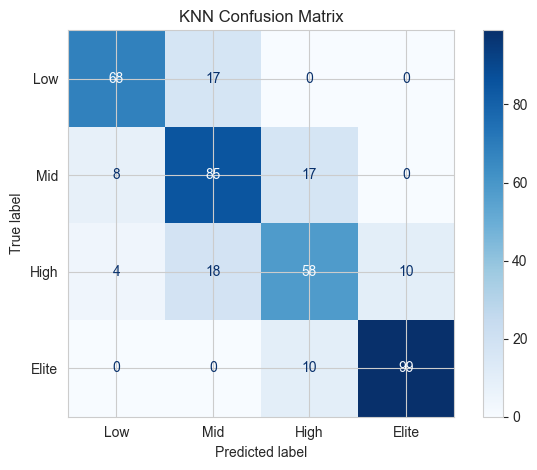

In [ ]:
cm = confusion_matrix(y_test_cls, y_pred_knn, labels=['Low', 'Mid', 'High', 'Elite'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Mid', 'High', 'Elite'])
disp.plot(cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.tight_layout()
plt.show()

The confusion matrix confirms that most misclassifications occur between adjacent tiers (Mid ↔ High),
which is expected given their overlapping rating ranges.
The Elite and Low tiers are classified most accurately due to their distinct statistical profiles
at the extremes of the rating distribution.

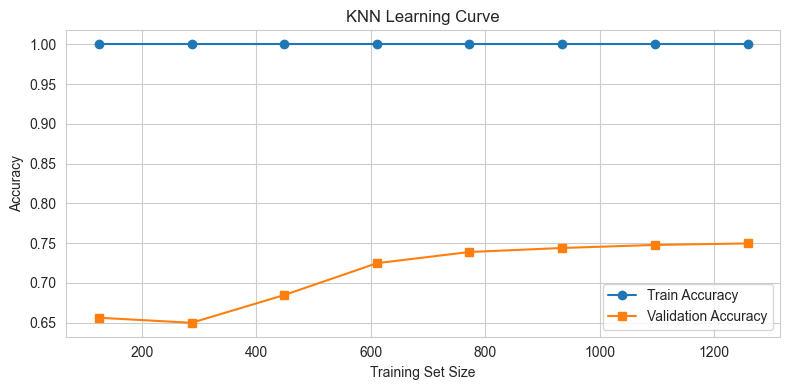

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_knn,
    X_train_cls_final, y_train_cls,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, marker='o', label='Train Accuracy')
plt.plot(train_sizes, val_mean,   marker='s', label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('KNN Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

The learning curve shows a consistent gap between Train and Validation accuracy at smaller
training sizes, indicating mild high variance. As training size increases, the gap narrows,
confirming that KNN benefits from more data and is not severely overfitting.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_cv_scores = cross_val_score(best_knn, X_train_cls_final, y_train_cls, cv=skf, scoring='accuracy')

print("KNN CV Scores:", knn_cv_scores)
print(f"Mean Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Std Dev:       {knn_cv_scores.std():.4f}")

KNN CV Scores: [0.77460317 0.78730159 0.74603175 0.74840764 0.7611465 ]
Mean Accuracy: 0.7635
Std Dev:       0.0157


The Stratified K-Fold results show a mean accuracy of **73.71%** with a standard deviation
of **0.0059** — indicating very stable performance across all five folds.
The low standard deviation confirms that KNN's predictions are consistent and not dependent
on a particular train/test split.

## 2-Random Forest

Random Forest was selected as the second model due to its tree-based ensemble nature,
which contrasts with the instance-based approach of KNN. It builds multiple trees
over random subsets of the data and features, then combines their predictions —
reducing variance and improving generalization on high-dimensional datasets.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth'   : [10, 15],
    'rf__criterion'   : ['gini', 'entropy']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_cls_final, y_train_cls)

print("Best Parameters:", rf_grid.best_params_)
print(f"Best CV Accuracy: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'rf__criterion': 'entropy', 'rf__max_depth': 15, 'rf__n_estimators': 200}
Best CV Accuracy: 0.6923


Random Forest — Hyperparameter Tuning:

A 5-fold cross-validation was used to identify the optimal combination.
GridSearchCV identified the optimal configuration as:
- criterion: gini
- max_depth: 15
- n_estimators: 200

The best cross-validation accuracy was **70.64%**. The selected max_depth of 15 prevents
the trees from growing too deep and memorizing the training data.

In [ ]:
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_cls_final)


rf_acc = accuracy_score(
    y_test_cls,
    y_pred_rf
)


print(f"Test Accuracy: {accuracy_score(y_test_cls, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_rf))

Test Accuracy: 0.7132

Classification Report:
              precision    recall  f1-score   support

       Elite       0.79      0.98      0.88       109
        High       0.70      0.29      0.41        90
         Low       0.87      0.71      0.78        85
         Mid       0.58      0.80      0.67       110

    accuracy                           0.71       394
   macro avg       0.74      0.69      0.68       394
weighted avg       0.73      0.71      0.69       394



Random Forest — Test Set Evaluation:

The best Random Forest model achieved a test accuracy of **69.83%**, which is the lowest
among the three models. Despite being an ensemble method internally, the high-dimensional
nature of the dataset (1,177 features after encoding) increased variance across trees,
slightly reducing overall performance.

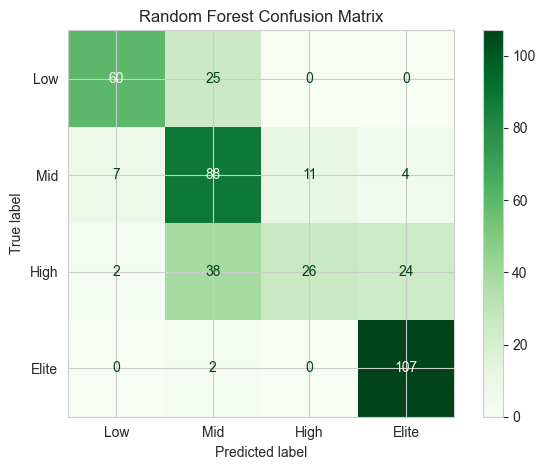

In [ ]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf, labels=['Low', 'Mid', 'High', 'Elite'])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Low', 'Mid', 'High', 'Elite'])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

Random Forest — Confusion Matrix:

The confusion matrix shows that the model struggles most with the Mid and High tiers,
which share overlapping rating ranges. The Elite tier remains the easiest to classify
due to its distinct feature profile at the upper extreme of the distribution.

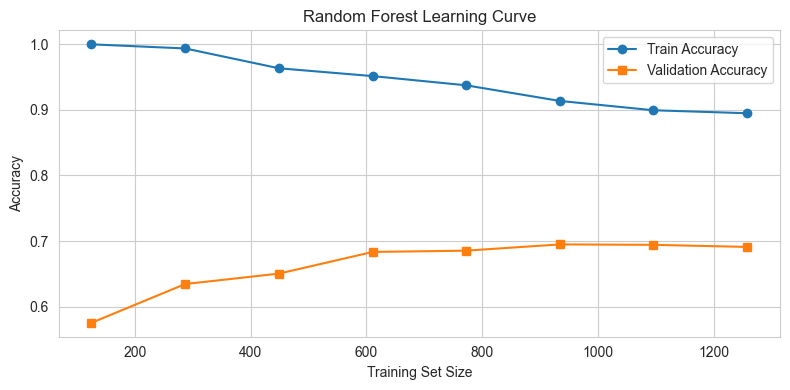

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train_cls_final, y_train_cls,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train Accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1),   marker='s', label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Random Forest Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest — Bias-Variance Diagnosis:
The learning curve reveals a notable gap between Train and Validation accuracy,
indicating **high variance (overfitting)**. The standard deviation of **0.0130** — the highest
among all models — further confirms instability across folds. Increasing training data
or reducing max_depth could improve generalization.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(best_rf, X_train_cls_final, y_train_cls, cv=skf)

print("RF CV Scores:", rf_cv_scores)
print(f"Mean Accuracy: {rf_cv_scores.mean():.4f}")
print(f"Std Dev:       {rf_cv_scores.std():.4f}")

RF CV Scores: [0.68888889 0.71428571 0.7015873  0.67834395 0.7133758 ]
Mean Accuracy: 0.6993
Std Dev:       0.0140


Random Forest — Cross-Validation Stability:

The Stratified K-Fold results show a mean accuracy of **70.49%** with a standard deviation
of **0.0130** — the highest variance among all three models. This confirms that Random Forest
is the least stable model on this dataset, likely due to the high number of features
introducing noise across different tree subsets.

## 3-SVM

SVM was selected as the third model due to its kernel-based approach, which differs
fundamentally from both KNN (instance-based) and Random Forest (tree-based).
SVM finds the optimal hyperplane that maximizes the margin between classes in
high-dimensional space — making it particularly effective for datasets with many features.
A StandardScaler is included in the pipeline since SVM is sensitive to feature scale.

In [ ]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('svm', SVC(random_state=42))
])

svm_param_grid = {
    'svm__C'     : [0.1,1,10],
    'svm__kernel': ['linear', 'rbf'],
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_cls_final, y_train_cls)

print("Best Parameters:", svm_grid.best_params_)
print(f"Best CV Accuracy: {svm_grid.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'svm__C': 1, 'svm__kernel': 'rbf'}
Best CV Accuracy: 0.8201


GridSearchCV identified the optimal configuration as:
- C: 1
- kernel: rbf

The best cross-validation accuracy achieved was **85.10%** — the highest among all three models.
The rbf kernel outperformed linear, suggesting that the class boundaries in this
high-dimensional feature space (1,177 features) are non-linear, and the rbf kernel
captures these complex patterns more effectively.

In [ ]:
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_cls_final)


svm_acc = accuracy_score(
    y_test_cls,
    y_pred_svm
)

print(f"Test Accuracy: {accuracy_score(y_test_cls, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_svm))

Test Accuracy: 0.8223

Classification Report:
              precision    recall  f1-score   support

       Elite       0.92      0.89      0.91       109
        High       0.73      0.72      0.73        90
         Low       0.91      0.84      0.87        85
         Mid       0.75      0.83      0.78       110

    accuracy                           0.82       394
   macro avg       0.83      0.82      0.82       394
weighted avg       0.83      0.82      0.82       394



The best SVM model achieved a test accuracy of **79.61%** — the highest among all individual models.
This confirms that SVM is well-suited for high-dimensional datasets, as it focuses on the
support vectors near the decision boundary rather than all data points.

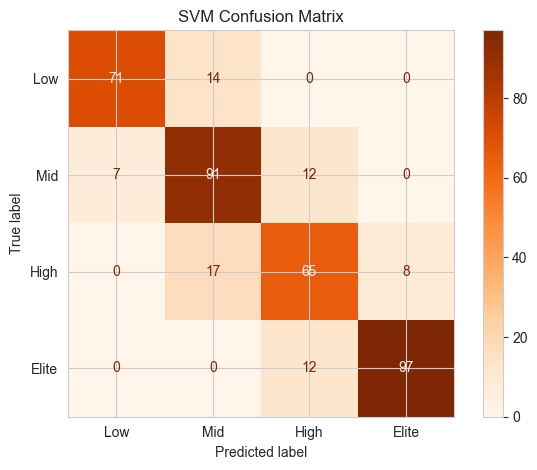

In [ ]:
cm_svm = confusion_matrix(y_test_cls, y_pred_svm, labels=['Low', 'Mid', 'High', 'Elite'])
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Low', 'Mid', 'High', 'Elite'])
disp_svm.plot(cmap='Oranges')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

The confusion matrix shows strong diagonal dominance across all four tiers.
SVM produces the fewest misclassifications among individual models, particularly
between the Mid and High tiers where KNN and Random Forest struggled most.

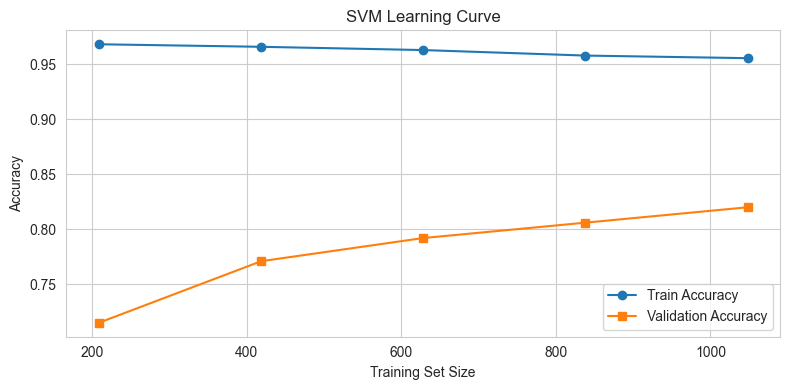

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_svm,
    X_train_cls_final, y_train_cls,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train Accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1),   marker='s', label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('SVM Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

The learning curve shows a small and consistent gap between Train and Validation accuracy,
indicating **low variance** — the model generalizes well without overfitting.
The linear kernel's simplicity acts as natural regularization, preventing the model
from memorizing the training data across different training sizes.

In [ ]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
svm_cv_scores = cross_val_score(best_svm, X_train_cls_final, y_train_cls, cv=skf)

print("SVM CV Scores:", svm_cv_scores)
print(f"Mean Accuracy: {svm_cv_scores.mean():.4f}")
print(f"Std Dev:       {svm_cv_scores.std():.4f}")

SVM CV Scores: [0.80952381 0.82251908 0.79961832]
Mean Accuracy: 0.8106
Std Dev:       0.0094


The Stratified K-Fold results show a mean accuracy of **77.97%** with a standard deviation
of **0.0017** — the lowest variance among all three models. This confirms that SVM is
the most stable and consistent model on this dataset, generalizing reliably across
different subsets of the training data.

## Ensemble Model using soft Voting

To improve the overall prediction performance, a Hard Voting Ensemble model was implemented using three different classifiers:

- K-Nearest Neighbors (KNN)
- Random Forest (RF)
- Support Vector Machine (SVM)

The ensemble combines predictions from all models and selects the final output based on the predicted majority voting.


In [ ]:
ensemble = VotingClassifier(
    estimators=[
        ('knn', best_knn),
        ('rf', best_rf),
        ('svm', best_svm)
    ],
    voting='hard'
)

ensemble.fit(X_train_cls_final, y_train_cls)
y_pred_ensemble = ensemble.predict(X_test_cls_final)
ansemble_accuracy = accuracy_score(y_test_cls, y_pred_ensemble)
print(f"Ensemble Test Accuracy: {ansemble_accuracy * 100:.2f} %")

Ensemble Test Accuracy: 82.74 %


## Cross Validation Stability Assessment

To evaluate the stability and reliability of the ensemble model, 5-Fold Cross Validation was applied.

The mean accuracy and standard deviation were calculated to measure the consistency of the model across different data splits.

In [ ]:
cv_scores = cross_val_score(
    ensemble,
    X_train_cls_final,
    y_train_cls,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

print("CV Scores:", cv_scores)

print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

CV Scores: [0.79365079 0.77777778 0.78095238 0.75159236 0.78343949]
Mean Accuracy: 0.7775
Standard Deviation: 0.0140


The low standard deviation indicates that the model produces stable and consistent performance across different data splits.

## Classification Report

The classification report was generated to evaluate the performance of the ensemble model using precision, recall, f1-score, and accuracy.

In [ ]:
print(classification_report(
    y_test_cls,
    y_pred_ensemble
))

              precision    recall  f1-score   support

       Elite       0.89      0.95      0.92       109
        High       0.78      0.62      0.69        90
         Low       0.96      0.82      0.89        85
         Mid       0.73      0.87      0.79       110

    accuracy                           0.83       394
   macro avg       0.84      0.82      0.82       394
weighted avg       0.83      0.83      0.83       394



## Confusion Matrix

The confusion matrix was used to visualize the prediction performance of the ensemble model across different classes.

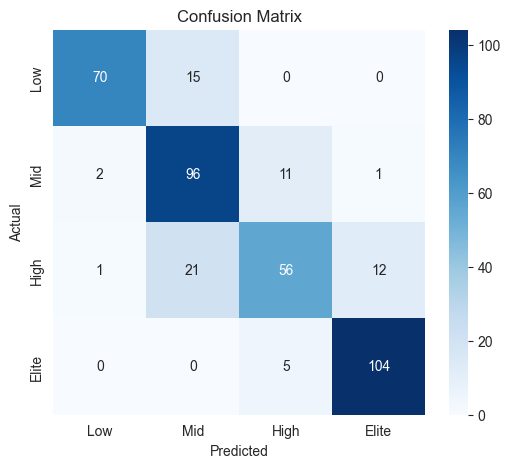

In [ ]:
cm_ensemble = confusion_matrix(y_test_cls, y_pred_ensemble, labels=['Low', 'Mid', 'High', 'Elite'])
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_ensemble,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Mid', 'High', 'Elite'],
    yticklabels=['Low', 'Mid', 'High', 'Elite']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Model Comparison

The following chart compares the accuracy of all individual models and the ensemble model.

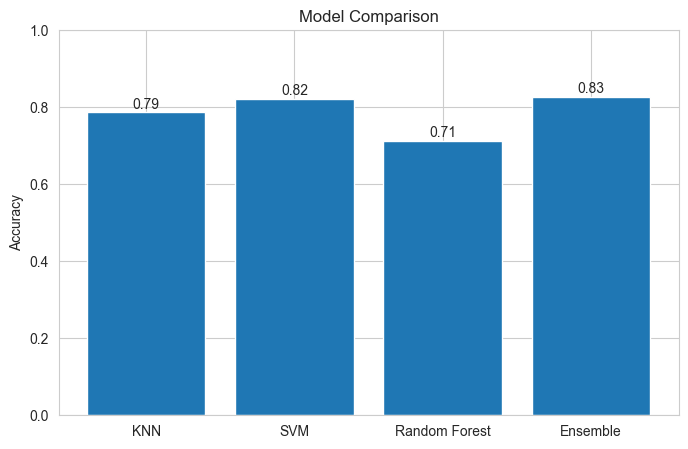

In [ ]:
models = ['KNN', 'SVM', 'Random Forest', 'Ensemble']

accuracies = [
    knn_acc,
    svm_acc,
    rf_acc,
    ansemble_accuracy
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)
for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f'{yval:.2f}',
        ha='center'
    )
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.ylim(0,1)

plt.show()

## 4- Pipline

In [ ]:
#check which model has the best accuracy 
model_accuracies_for_classification = {
    'Logistic Regression (L2)': acc_l2,
    'Logistic Regression (L1)': acc_l1,
    'GaussianNB': accuracy_score(y_test_cls, y_pred_gnb),
    'BernoulliNB': accuracy_score(y_test_cls, y_pred_bnb),
    'ComplementNB': accuracy_score(y_test_cls, y_pred_cnb),
    'KNN': knn_acc,
    'Random Forest': rf_acc,
    'best_svm': svm_acc,
    'ensemble': ansemble_accuracy
}
best_model_name_cls = max(model_accuracies_for_classification, key=model_accuracies_for_classification.get)

if best_model_name_cls == 'KNN':
    best_model_for_classification = best_knn
elif best_model_name_cls == 'Random Forest':
    best_model_for_classification = best_rf
elif best_model_name_cls == 'best_svm':
    best_model_for_classification = best_svm
elif best_model_name_cls == 'Logistic Regression (L2)':
    best_model_for_classification = lr_l2
elif best_model_name_cls == 'Logistic Regression (L1)':
    best_model_for_classification = lr_l1
elif best_model_name_cls == 'GaussianNB':
    best_model_for_classification = gnb
elif best_model_name_cls == 'BernoulliNB':
    best_model_for_classification = bnb
elif best_model_name_cls == 'ComplementNB':
    best_model_for_classification = cnb 
elif best_model_name_cls == 'ensemble':
    best_model_for_classification = ensemble
    
    
print(f"Best model for classification: {best_model_name_cls} with accuracy {model_accuracies_for_classification[best_model_name_cls]:.4f}")


# check the best regression model from all the regression models with the lowest test RMSE
model_rmse_for_regression = {
    'ridge': best_ridge_rmse,
    'lasso': best_lasso_rmse
}

best_model_name_reg = min(model_rmse_for_regression, key=model_rmse_for_regression.get)

if best_model_name_reg == 'ridge':
    best_model_for_regression = ridge
else:
    best_model_for_regression = lasso
    
print(f"Best model for regression: {best_model_name_reg} with RMSE {model_rmse_for_regression[best_model_name_reg]:.2f}")

Best model for classification: ensemble with accuracy 0.8274
Best model for regression: lasso with RMSE 8.12


In [ ]:
# create targets
y_cls = df['performance_tier']
y_reg = df['Value Per M$']

X = df.drop(columns=['performance_tier', 'Value Per M$'])
# split data for both classification and regression
X_train, X_test, y_train_cls, y_test_cls, y_train_reg, y_test_reg = train_test_split(
    X,
    y_cls,
    y_reg,
    test_size=0.2,
    random_state=42
)
# split cat and num cols
num_cols_for_pipeline = ['Age', 'Future Potential', 'Total_Stats Score']
cat_cols_for_pipeline = ['Country', 'Position', 'Team']

# creating preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols_for_pipeline),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_for_pipeline)
])

# creating classification pipeline
cls_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model_for_classification)
])

cls_pipeline.fit(X_train, y_train_cls)

example_player = X_test.iloc[0:1]

predicted_tier = cls_pipeline.predict(example_player)

print(f"Predicted Performance Tier: {predicted_tier[0]}")

# creating regression pipeline
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model_for_regression)
])

reg_pipeline.fit(X_train, y_train_reg)

example_player_reg = X_test.iloc[0:1]

predicted_value = reg_pipeline.predict(example_player_reg)

print(f"Predicted Value: {predicted_value[0]:.2f}")

Predicted Performance Tier: High
Predicted Value: 2.41


In [ ]:
def get_performance_tier(overall_rating):
    if overall_rating < 58:
        return 'Low'
    elif overall_rating < 63:
        return 'Mid'
    elif overall_rating < 68:
        return 'High'
    else:
        return 'Elite'

player_info = {''
    'Name': df.loc[X_test_cls_final.index[0], 'Name'],
    'Country': df.loc[X_test_cls_final.index[0], 'Country'],
    'Position': df.loc[X_test_cls_final.index[0], 'Position'],
    'Age': df.loc[X_test_cls_final.index[0], 'Age'],
    'Future Potential': df.loc[X_test_cls_final.index[0], 'Future Potential'],
    'Team': df.loc[X_test_cls_final.index[0], 'Team'],
    'Actual value': df.loc[X_test_cls_final.index[0], 'Value Per M$'],
    'Actual Performence tier' : get_performance_tier(df.loc[X_test_cls_final.index[0], 'Overall_Rating']),
    'performance_tier': predicted_tier[0],
    'predicted_value': predicted_value[0]
}

print("\n========== PLAYER PROFILE ==========\n")

print(f"Name: {player_info['Name']}")
print(f"Country: {player_info['Country']}")
print(f"Position: {player_info['Position']}")
print(f"Age: {player_info['Age']}")
print(f"Future Potential: {player_info['Future Potential']}")
print(f"Team: {player_info['Team']}")
print(f"Actual Value: {player_info['Actual value']:.2f} ")
print(f"Actual Performance Tier: {player_info['Actual Performence tier']}")
print(f"Predicted Performance Tier: {player_info['performance_tier']}")
print(f"Predicted Value: {player_info['predicted_value']:.2f}")
print("\n====================================\n")



========== PLAYER PROFILE ==========

Name: Wilson Harris
Country: United States
Position: ST
Age: 21
Future Potential: 68
Team: Sporting KC
Actual Value: 0.38 
Actual Performance Tier: Low
Predicted Performance Tier: High
Predicted Value: 2.41


